<div style="text-align:center">

# TECNOLÓGICO DE ESTUDIOS SUPERIORES DE JOCOTITLÁN
### Ingeniería en Sistemas Computacionales
<br>

## Ejercicio de regresión lineal simple
**Efecto de la dosis diaria de una droga en las pulsaciones del corazón**
<br>

**Integrantes:** (Dulce María Aguilar Molina y Rodrigo Prospero Velazquez)   

**Asignatura:** (APRENDIZAJE AUTOMÁTICO)

**Profesor:** (Dr. Juan Alberto Antonio Velázquez)

**Grupo:** (IC-0701)

**Fecha:** (08/10/2026)

</div>

## 1. Planteamiento del problema

En un experimento médico se estudia el efecto de cierta droga sobre las pulsaciones del corazón. Un paciente recibe diversas dosis diarias de la droga durante 5 días y se registra el número de pulsaciones por minuto en cada uno. Con esos datos se busca:

- a) Determinar la ecuación de regresión lineal.
- b) Estimar las pulsaciones para una dosis diaria de 3.5 gramos.
- c) Calcular el error estándar de estimación.
- d) Calcular a₀, a₁, XY y X².
- e) Obtener los coeficientes de determinación y de correlación.
- f) Graficar la recta normal y la recta con la predicción.

La variable independiente **X** es la dosis diaria (gramos) y la variable dependiente **Y** son las pulsaciones por minuto.

## 2. Fundamento matemático

El modelo de regresión lineal simple es

$$\hat{y} = a_0 + a_1 x$$

Con *n* observaciones, los coeficientes por mínimos cuadrados son

$$a_1 = \frac{n\sum xy - \sum x \sum y}{n\sum x^2 - \left(\sum x\right)^2} \qquad a_0 = \frac{\sum y - a_1 \sum x}{n}$$

El error estándar de estimación mide la dispersión de los datos reales alrededor de la recta:

$$S_{y.x} = \sqrt{\frac{\sum (y_i - \hat{y}_i)^2}{n-2}}$$

El coeficiente de correlación y el de determinación son

$$r = \frac{n\sum xy - \sum x \sum y}{\sqrt{\left[n\sum x^2 - (\sum x)^2\right]\left[n\sum y^2 - (\sum y)^2\right]}} \qquad R^2 = r^2$$

## 3. Organización de los datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datos del experimento (mismos que en el archivo de Excel)
x = np.array([3, 2, 1, 5, 4])          # Dosis diaria (g)  -> variable independiente X
y = np.array([70, 60, 50, 80, 100])    # Pulsaciones por minuto -> variable dependiente Y
n = len(x)                             # Número de observaciones

datos = pd.DataFrame({"Dosis diaria (x)": x, "Pulsaciones por minuto (y)": y})
datos

,Dosis diaria (x),Pulsaciones por minuto (y)
0,3,70
1,2,60
2,1,50
3,5,80
4,4,100


## 4. Cálculos auxiliares: XY, X², Y² y sumatorias

In [2]:
# Columnas auxiliares para el procedimiento
tabla = datos.copy()
tabla.columns = ["x", "y"]
tabla["xy"]  = tabla["x"] * tabla["y"]
tabla["x^2"] = tabla["x"] ** 2
tabla["y^2"] = tabla["y"] ** 2

# Sumatorias
sum_x, sum_y   = tabla["x"].sum(),  tabla["y"].sum()
sum_xy         = tabla["xy"].sum()
sum_x2, sum_y2 = tabla["x^2"].sum(), tabla["y^2"].sum()

display(tabla)
print(f"n     = {n}")
print(f"Σx    = {sum_x}")
print(f"Σy    = {sum_y}")
print(f"Σxy   = {sum_xy}")
print(f"Σx²   = {sum_x2}")
print(f"Σy²   = {sum_y2}")

,x,y,xy,x^2,y^2
0,3,70,210,9,4900
1,2,60,120,4,3600
2,1,50,50,1,2500
3,5,80,400,25,6400
4,4,100,400,16,10000


n     = 5
Σx    = 15
Σy    = 360
Σxy   = 1180
Σx²   = 55
Σy²   = 27400


## 5. Coeficientes a₁ y a₀, y ecuación de regresión

In [3]:
# Pendiente (a1) e intercepto (a0) por mínimos cuadrados
a1 = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
a0 = (sum_y - a1 * sum_x) / n

print(f"a1 = ({n}*{sum_xy} - {sum_x}*{sum_y}) / ({n}*{sum_x2} - {sum_x}^2) = {a1:.4f}")
print(f"a0 = ({sum_y} - {a1:.4f}*{sum_x}) / {n} = {a0:.4f}")
print()
print(f"Ecuación de regresión:  ŷ = {a0:.2f} + {a1:.2f}x")

a1 = (5*1180 - 15*360) / (5*55 - 15^2) = 10.0000
a0 = (360 - 10.0000*15) / 5 = 42.0000

Ecuación de regresión:  ŷ = 42.00 + 10.00x


**Interpretación.** El intercepto a₀ = 42 indica las pulsaciones por minuto esperadas cuando la dosis es de 0 gramos. La pendiente a₁ = 10 indica que, por cada gramo adicional de droga al día, las pulsaciones aumentan en promedio 10 por minuto.

## 6. Predicción para una dosis diaria de 3.5 g

In [4]:
x_nuevo = 3.5
y_pred = a0 + a1 * x_nuevo

print(f"ŷ = {a0:.2f} + {a1:.2f}({x_nuevo}) = {a0:.2f} + {a1 * x_nuevo:.2f} = {y_pred:.2f}")
print(f"Con 3.5 g diarios se estiman {y_pred:.0f} pulsaciones por minuto.")

ŷ = 42.00 + 10.00(3.5) = 42.00 + 35.00 = 77.00
Con 3.5 g diarios se estiman 77 pulsaciones por minuto.


## 7. Error estándar de estimación

In [5]:
# Valores estimados por la recta y residuos al cuadrado
tabla["ŷ"] = a0 + a1 * tabla["x"]
tabla["(y - ŷ)^2"] = (tabla["y"] - tabla["ŷ"]) ** 2
display(tabla[["x", "y", "ŷ", "(y - ŷ)^2"]])

sse = tabla["(y - ŷ)^2"].sum()          # Suma de errores al cuadrado
s_yx = np.sqrt(sse / (n - 2))           # Error estándar de estimación

print(f"Σ(y - ŷ)² = {sse:.2f}")
print(f"S(y.x) = √({sse:.2f} / {n - 2}) = {s_yx:.4f}")

,x,y,ŷ,(y - ŷ)^2
0,3,70,72.0,4.0
1,2,60,62.0,4.0
2,1,50,52.0,4.0
3,5,80,92.0,144.0
4,4,100,82.0,324.0


Σ(y - ŷ)² = 480.00
S(y.x) = √(480.00 / 3) = 12.6491


**Interpretación.** El error estándar de estimación (≈ 12.65 pulsaciones) indica que, en promedio, los valores reales se alejan alrededor de 12.65 pulsaciones por minuto de los valores que predice la recta. Mientras más pequeño sea, más confiables son las predicciones.

## 8. Coeficientes de correlación y determinación

In [6]:
# Coeficiente de correlación r
r = (n * sum_xy - sum_x * sum_y) / np.sqrt((n * sum_x2 - sum_x ** 2) * (n * sum_y2 - sum_y ** 2))

# Coeficiente de determinación R²
r2 = r ** 2

print(f"r  = {r:.4f}")
print(f"R² = {r2:.4f}  ({r2 * 100:.2f} %)")

r  = 0.8220
R² = 0.6757  (67.57 %)


**Interpretación.** El valor r ≈ 0.822 es positivo, por lo que la relación es directa: a mayor dosis, más pulsaciones. Su magnitud indica una correlación fuerte. El coeficiente R² ≈ 0.676 señala que alrededor del 67.57 % de la variación en las pulsaciones se explica por la dosis diaria; el 32.43 % restante se debe a otros factores.

## 9. Gráficas

### 9.1 Datos observados y recta de regresión

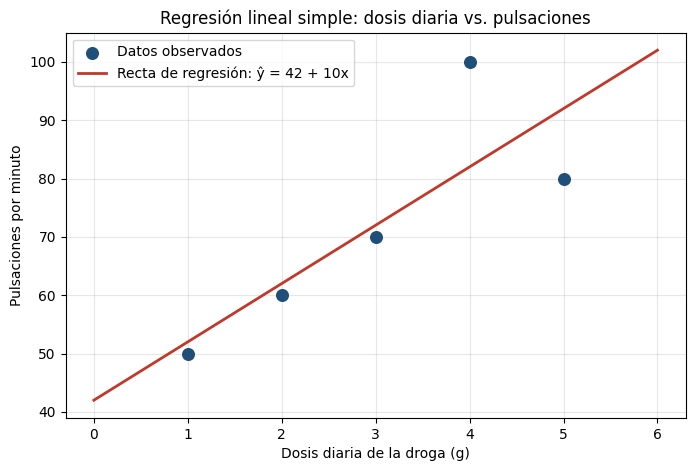

In [7]:
x_linea = np.linspace(0, 6, 100)
y_linea = a0 + a1 * x_linea

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="#1f4e79", s=70, label="Datos observados", zorder=3)
plt.plot(x_linea, y_linea, color="#c0392b", linewidth=2, label=f"Recta de regresión: ŷ = {a0:.0f} + {a1:.0f}x")
plt.title("Regresión lineal simple: dosis diaria vs. pulsaciones")
plt.xlabel("Dosis diaria de la droga (g)")
plt.ylabel("Pulsaciones por minuto")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 9.2 Recta de regresión con la predicción para 3.5 g

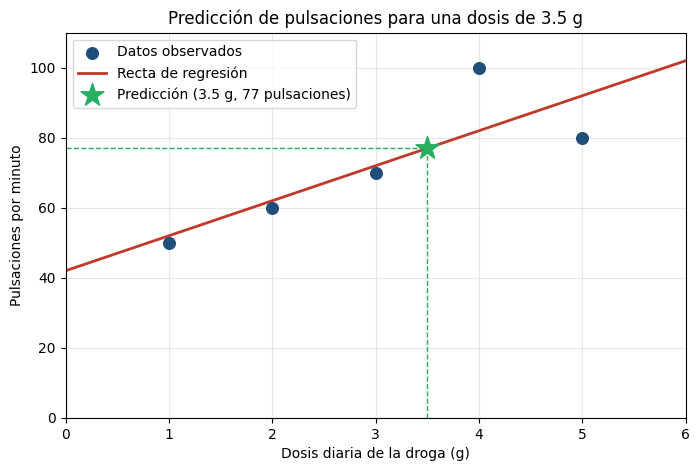

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="#1f4e79", s=70, label="Datos observados", zorder=3)
plt.plot(x_linea, y_linea, color="#c0392b", linewidth=2, label="Recta de regresión")
plt.scatter(x_nuevo, y_pred, color="#27ae60", marker="*", s=300, label=f"Predicción (3.5 g, {y_pred:.0f} pulsaciones)", zorder=4)

# Líneas guía hacia los ejes para ubicar la predicción
plt.vlines(x_nuevo, 0, y_pred, colors="#27ae60", linestyles="dashed", linewidth=1)
plt.hlines(y_pred, 0, x_nuevo, colors="#27ae60", linestyles="dashed", linewidth=1)

plt.title("Predicción de pulsaciones para una dosis de 3.5 g")
plt.xlabel("Dosis diaria de la droga (g)")
plt.ylabel("Pulsaciones por minuto")
plt.xlim(0, 6)
plt.ylim(0, 110)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 10. Verificación con librerías y con el Excel

In [9]:
from scipy import stats

# Comparación con scipy: los valores deben coincidir con el cálculo manual
res = stats.linregress(x, y)
print(f"scipy -> a1 = {res.slope:.4f}, a0 = {res.intercept:.4f}, r = {res.rvalue:.4f}, R² = {res.rvalue**2:.4f}")

# Resultados obtenidos en el archivo de Excel
excel = {"a1": 10, "a0": 42, "r": 0.8219949365, "R²": 0.6756756757, "S(y.x)": 12.6491106407}
manual = {"a1": a1, "a0": a0, "r": r, "R²": r2, "S(y.x)": s_yx}

comparacion = pd.DataFrame({"Python (manual)": manual, "Excel": excel})
comparacion["¿Coinciden?"] = [np.isclose(manual[k], excel[k]) for k in excel]
comparacion

scipy -> a1 = 10.0000, a0 = 42.0000, r = 0.8220, R² = 0.6757


,Python (manual),Excel,¿Coinciden?
a1,10.000000,10.000000,True
a0,42.000000,42.000000,True
r,0.821995,0.821995,True
R²,0.675676,0.675676,True
S(y.x),12.649111,12.649111,True


## 11. Conclusiones

La ecuación de regresión obtenida fue **ŷ = 42 + 10x**: con cada gramo adicional de droga, el corazón del paciente late en promedio 10 veces más por minuto. Para una dosis de 3.5 g se estimaron **77 pulsaciones por minuto**.

La correlación (r ≈ 0.822) es positiva y fuerte, y el coeficiente de determinación (R² ≈ 0.676) indica que cerca de dos tercios de la variación en las pulsaciones se explican por la dosis. El error estándar de estimación (≈ 12.65) muestra que las predicciones tienen una dispersión moderada, lo cual es razonable considerando que solo se dispone de 5 observaciones de un único paciente, por lo que los resultados no deben generalizarse sin más datos.

Los cálculos realizados en Python coinciden con los del archivo de Excel, lo que confirma que ambos procedimientos son consistentes con el desarrollo matemático.